# Grover adiabático

In [1]:
from qiskit import QuantumRegister, ClassicalRegister, QuantumCircuit, transpile, assemble
from qiskit.visualization import plot_histogram

\begin{equation}
H(s) = (1-s)H_0 + sH_p
\end{equation}

$n$ = quantidade de qubits.

Coeficiente Identidad: $\left(1 - \frac{1}{2^n} \right)$. Exemplo: $II = \left(1 - \frac{1}{2^2} \right) = \frac{1}{4} = 0,75$, sempre positivo

Coeficiente operadores: $\left(\pm \frac{1}{2^n} \right)$. Exemplo: $IX = \left(\frac{1}{2^2} \right) = \frac{1}{4} = \pm 0,25$, ter em conta o sinal do operador correspondente

Hamiltoniano $H_p$
\begin{equation}
P_1 = | 1 \rangle \langle 1 | = \frac{1}{2}(I-Z)   
\end{equation}

Para 2 qubits o estado $|11 \rangle$, o projetor é
\begin{equation}
| 11 \rangle \langle 11 | = \left(\frac{I-Z}{2} \right) \otimes \left(\frac{I-Z}{2} \right) = \frac{1}{4}(II-IZ-ZI+ZZ)   
\end{equation}
\begin{equation}
H_p = I - | 11 \rangle \langle 11 | = 0,75(II) + 0,25(IZ) + 0,25(ZI) -0,25(ZZ)
\end{equation}

Hamiltoniano $H_0$
\begin{equation}
| + \rangle \langle + | = \left(\frac{I+X}{2} \right) \otimes \left(\frac{I+X}{2} \right) = \frac{1}{4}(II+IX+XI+XX)   
\end{equation}
\begin{equation}
H_0 = I - | + \rangle \langle + | = 0,75(II) - 0,25(IX) - 0,25(XI) - 0,25(XX)
\end{equation}

In [11]:
import numpy as np
from qiskit.quantum_info import SparsePauliOp
from qiskit.circuit.library import PauliEvolutionGate

# Número de qubits
n = 2
N = 2**n

# Hamiltoniano do Problema H_p: Marcamos o estado |11>
# Hp = I - |11><11|
hp_op = SparsePauliOp.from_list([
    ("II", 0.75),
    ("IZ", -0.25),
    ("ZI", -0.25),
    ("ZZ", -0.25)
])

# Hamiltoniano de Mistura H_0: Seu estado fundamental é a superposição uniforme
# H_0 = I - |+><+|
h0_op = SparsePauliOp.from_list([
    ("II", 0.75),
    ("IX", -0.25),
    ("XI", -0.25),
    ("XX", -0.25)
])

In [12]:
print(hp_op)

SparsePauliOp(['II', 'IZ', 'ZI', 'ZZ'],
              coeffs=[ 0.75+0.j, -0.25+0.j, -0.25+0.j, -0.25+0.j])


In [13]:
print(h0_op)

SparsePauliOp(['II', 'IX', 'XI', 'XX'],
              coeffs=[ 0.75+0.j, -0.25+0.j, -0.25+0.j, -0.25+0.j])


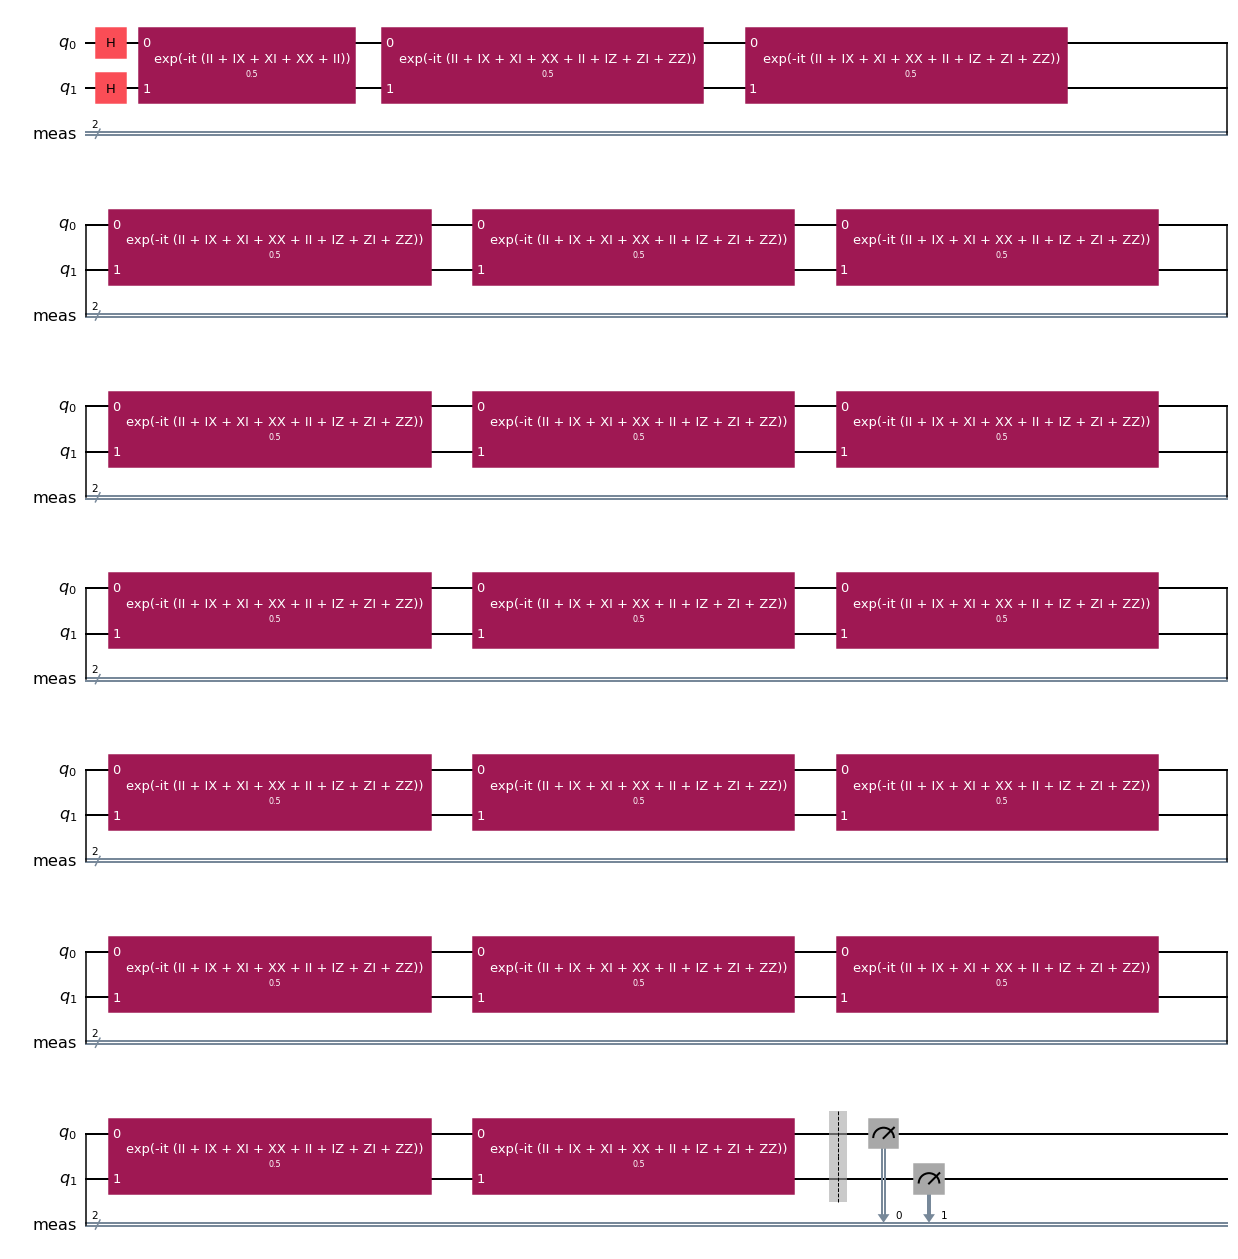

In [14]:
from qiskit import QuantumCircuit
from qiskit.circuit.library import PauliEvolutionGate
from qiskit.synthesis import ProductFormula, SuzukiTrotter

def grover_adiabatic_circuit(steps, T):
    dt = T / steps
    qc = QuantumCircuit(n)
    
    # Estado inicial: Superposição uniforme (fundamental de H_0)
    qc.h(range(n))
    
    # Evolução passo a passo
    for step in range(steps):
        s = step / steps
        
        # Hamiltoniano instantâneo H(s) = (1-s)H_0 + sH_p
        h_s = (1 - s) * h0_op + s * hp_op
        
        # Operador de evolução U = exp(-i * H(s) * dt)
        evolution_gate = PauliEvolutionGate(h_s, time=dt)
        qc.append(evolution_gate, range(n))
    
    #print(s)
    qc.measure_all()
    return qc

# Parâmetros
T = 10  # Tempo total da evolução
steps = 20 # Pasos de Trotter
circuit = grover_adiabatic_circuit(steps, T)


circuit.draw('mpl')

## Simulador

In [15]:
def counting_to_probability(contagem):
    m = sum(list(contagem.values()))
    n = len(list(contagem.keys())[0])
    L = [bin(i)[2:] for i in range(2**n)]
    L = list(map(lambda x: '0'*(n-len(x))+x,L))
    return {j:contagem[j]/m for j in contagem.keys()}

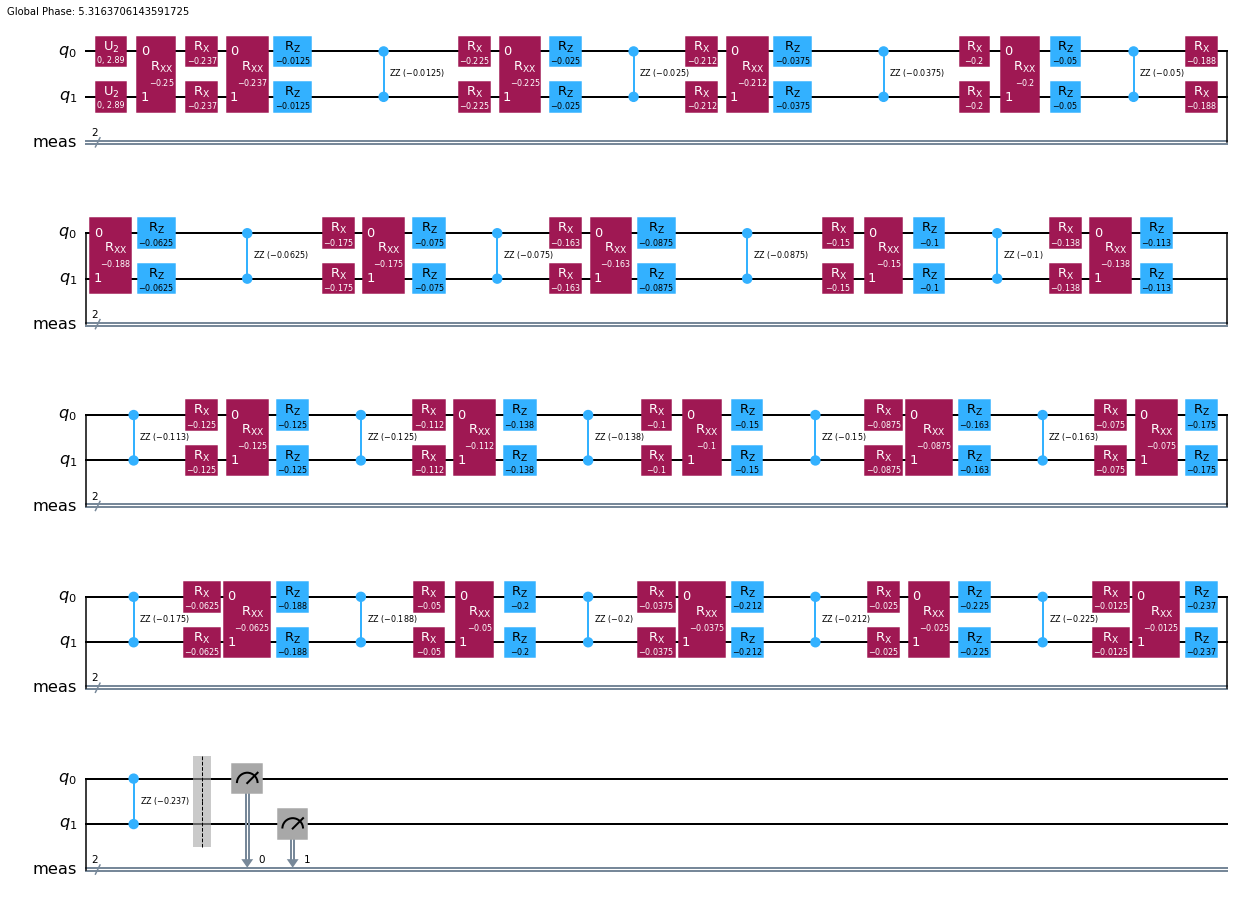

In [16]:
from qiskit_aer.aerprovider import AerSimulator

simulator = AerSimulator()
circ = transpile(circuit, simulator)

circ.draw('mpl')

In [17]:
result = simulator.run(circ,shots=4000).result()
counts = result.get_counts(circ)

In [18]:
probs = counting_to_probability(counts)
sorted_probs = dict(sorted(probs.items()))
print(sorted_probs)

{'00': 0.88925, '01': 0.03725, '10': 0.03975, '11': 0.03375}


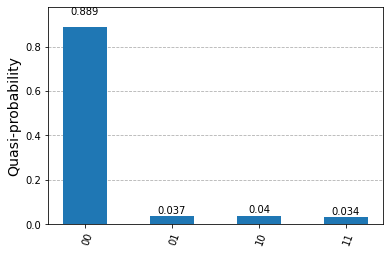

In [19]:
plot_histogram(probs)